# HealICON Comprehensive Tutorial

This notebook demonstrates the core features of the `HealICON` library, from grid interpolation to advanced atmospheric analysis on the sphere.

## 1. Interpolation to HEALPix

HealICON can natively interpolate unstructured (e.g. ICON icosahedral) and regular grids onto the HEALPix grid. You can also do this from the command line using `healicon convert`.

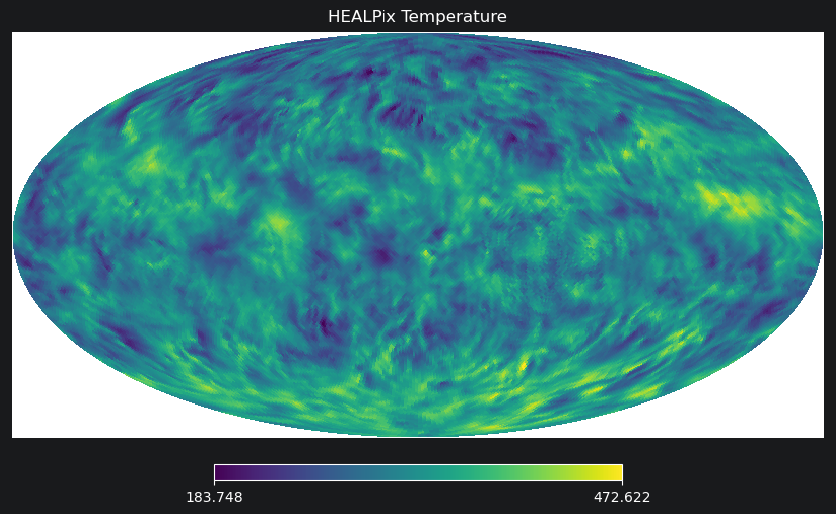

In [1]:
import xarray as xr
from healicon.interpolate import interpolate_to_healpix
import healpy as hp
import matplotlib.pyplot as plt

# We assume you have some sample NetCDF data in this directory
ds = xr.open_dataset('UA-ICON_NWP_atm_DOM01_ML_20250202T000000Z.nc').isel(time=0, height=20)

# Interpolate to HEALPix (e.g., nside=64)
ds_hp = interpolate_to_healpix(ds, nside=64)

hp.mollview(ds_hp['temp'].values, title="HEALPix Temperature", nest=False)
plt.show()


(<Figure size 1400x500 with 3 Axes>,
 (<GeoAxes: title={'center': 'Original Icosahedral Grid (R2B07)'}>,
  <GeoAxes: title={'center': 'HEALPix Grid (nside=128)'}>))

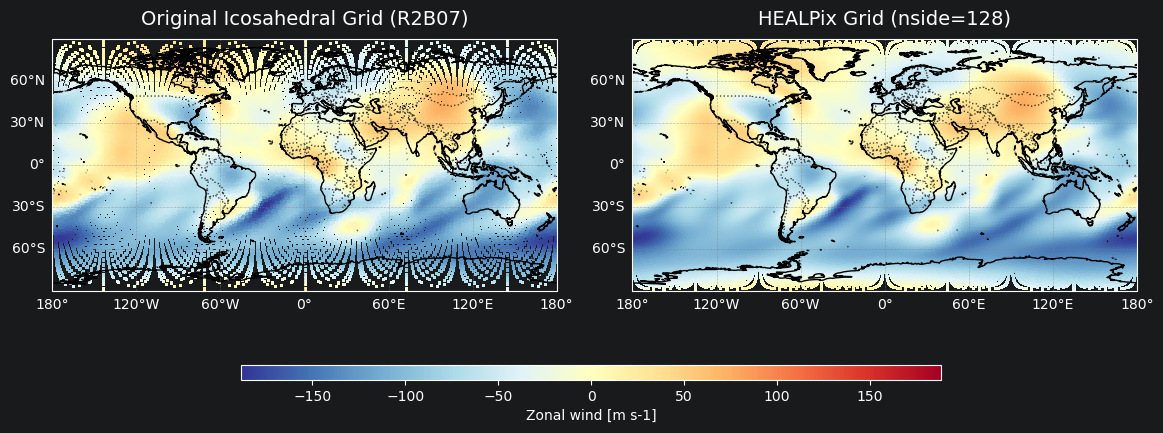

In [2]:
import xarray as xr

from healicon.interpolate import interpolate_to_healpix
from plot import plot_quicklook

ds = xr.open_dataset("icon_grid_mwe.nc").isel(height=20, time=-1)

nside = 128
ds_hp = interpolate_to_healpix(ds, nside=nside)

save_path = "u_wind_new_comparison.png"

plot_quicklook(
        ds[["u"]],
        ds_hp,
        var_name='u',
        height_idx=0,
        time_idx=0,
        save_path=save_path,
        plot_nodes=False,
        node_subsample=100,
        orig_title='Original Icosahedral Grid (R2B07)'
    )

## 2. Spectral Analysis and Filtering

Once data is on a HEALPix grid, you can perform fast spherical harmonic transforms to compute the power spectrum or filter the field spatially.

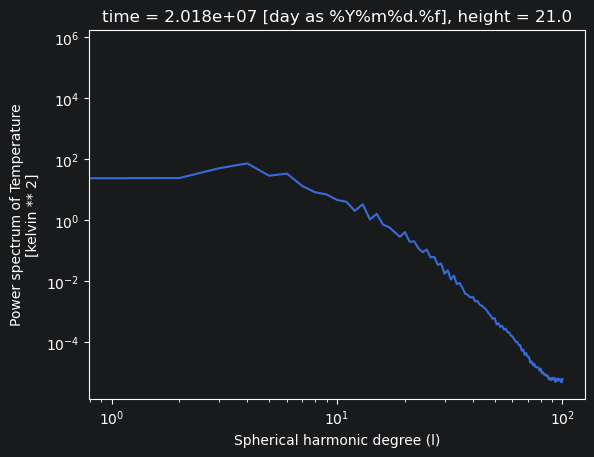

In [3]:
from healicon.analysis import compute_spectrum, filter_spatial

# Compute angular power spectrum up to lmax=100
spectrum = compute_spectrum(ds_hp, var_name='temp', lmax=100)

spectrum.temp_cl.plot(x='l', xscale='log', yscale="log")

## 3. Vector Calculus & Helmholtz Decomposition

HealICON can differentiate vector fields on the sphere, converting U/V winds to divergence and vorticity, and performing Helmholtz decomposition to extract rotational and divergent flow components.

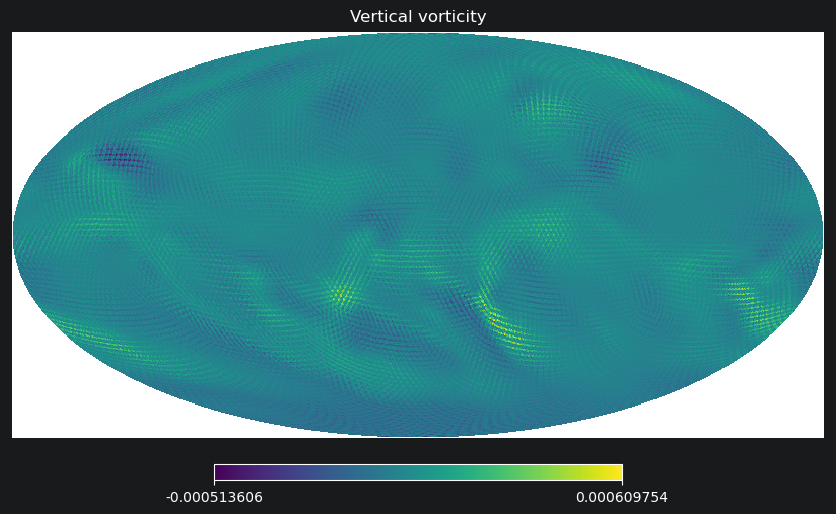

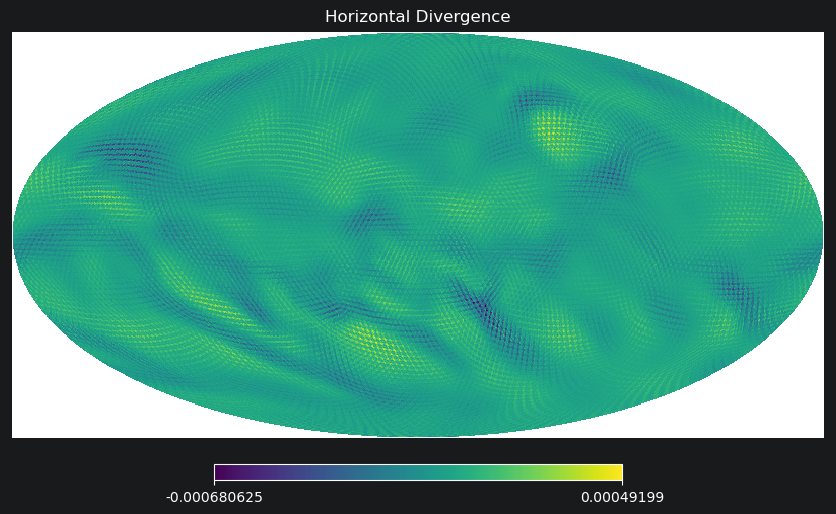

In [4]:
from healicon.analysis import compute_vorticity_divergence, compute_helmholtz

# Given a dataset with 'u' and 'v' wind components
ds_kinematics = compute_vorticity_divergence(ds_hp, u_var='u', v_var='v')
vorticity = ds_kinematics['vorticity']
divergence = ds_kinematics['divergence']

# Perform Helmholtz decomposition
ds_helmholtz = compute_helmholtz(ds_hp, u_var='u', v_var='v')
u_rot, v_rot = ds_helmholtz['u_rot'], ds_helmholtz['v_rot']
u_div, v_div = ds_helmholtz['u_div'], ds_helmholtz['v_div']

hp.mollview(vorticity.values, title="Vertical vorticity", nest=False)
hp.mollview(divergence.values, title="Horizontal Divergence", nest=False)
plt.show()

## 4. Atmospheric Tidal Analysis

HealICON features a built-in tidal analysis suite that performs a least-squares temporal fit for specified wave periods, spatially filters by zonal wavenumber, and decomposes the tides into symmetric and antisymmetric modes across the equator.

In [ ]:
# 1. Run the tidal analysis
# You can use the CLI directly:
# healicon tides --modes DW1,SW2,DE3,SE2 UA-ICON_NWP_temp_DOM01_HL_60-100km_202501.nc output_tides.nc

# 2. Compute the Zonal Mean
# The phase represents the global Universal Time phase (independent of longitude), allowing for flawless zonal averaging.
# healicon zonal-mean output_tides.nc output_tides_zm.nc


### Visualizing the Tides (Height-Latitude Cross Section)
We can visualize the resulting amplitude and phase of the extracted tidal components.

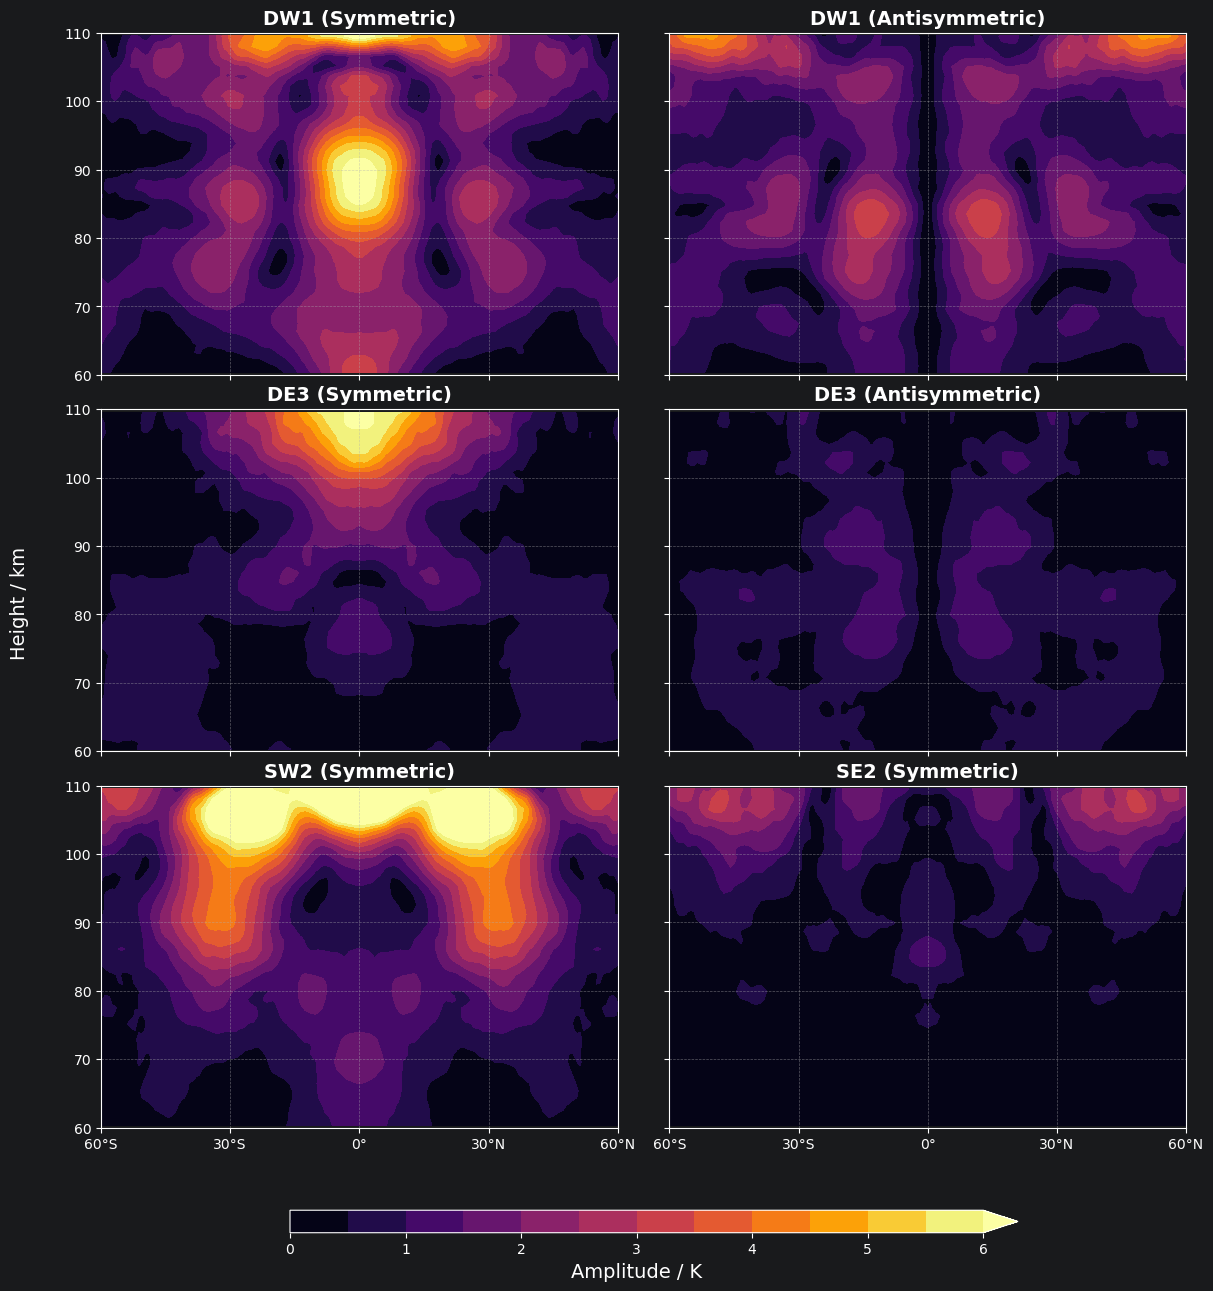

In [5]:
import warnings
import numpy as np
warnings.filterwarnings("ignore", category=FutureWarning)

# Load dataset and sort coordinates to strictly increasing for matplotlib contourf
ds_tides = xr.open_dataset('output_tides_zm_op.nc')
ds_tides = ds_tides.sortby(['lat', 'height'])

p_12 = np.timedelta64(12, 'h')
p_24 = np.timedelta64(24, 'h')

modes = {
    'DW1': {'period': p_24, 'm': -1, 'type': 'Symmetric'},
    'DW1_asy': {'period': p_24, 'm': -1, 'type': 'Antisymmetric'},
    'DE3': {'period': p_24, 'm': 3, 'type': 'Symmetric'},
    'DE3_asy': {'period': p_24, 'm': 3, 'type': 'Antisymmetric'},
    'SW2': {'period': p_12, 'm': -2, 'type': 'Symmetric'},
    'SE2': {'period': p_12, 'm': 2, 'type': 'Symmetric'},
}

fig, axes = plt.subplots(3, 2, figsize=(14, 15), sharex=True, sharey=True)
axes = axes.flatten()

lat_ticks = [-60, -30, 0, 30, 60]
lat_labels = ['60°S', '30°S', '0°', '30°N', '60°N']
levels = np.linspace(0, 6.0, 13)

for i, (name, meta) in enumerate(modes.items()):
    ax = axes[i]
    var_name = 'temp_amp_sym' if meta['type'] == 'Symmetric' else 'temp_amp_asy'
    data = ds_tides[var_name].sel(period=meta['period'], m=meta['m'], method='nearest')
    
    y = data.height / 1000.0  # Convert to km
    x = data.lat
    cf = ax.contourf(x, y, data, levels=levels, cmap='inferno', extend='max')
    
    ax.set_title(f"{name.split('_')[0]} ({meta['type']})", fontsize=14, fontweight='bold')
    ax.set_xlim(-60, 60)
    ax.set_ylim(60, 110)
    ax.set_xticks(lat_ticks)
    ax.set_xticklabels(lat_labels)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.label_outer()

# Add a single colorbar
fig.subplots_adjust(bottom=0.15, hspace=0.1, wspace=0.1)
cbar_ax = fig.add_axes([0.26, 0.08, 0.52, 0.015])
cbar = fig.colorbar(cf, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Amplitude / K', fontsize=14)

# Set common y label
fig.text(0.06, 0.5, 'Height / km', va='center', rotation='vertical', fontsize=14)
plt.show()


### Visualizing the Tides (Global Map)
We can also project the extracted tidal fields onto a global map using `healpy.mollview`.

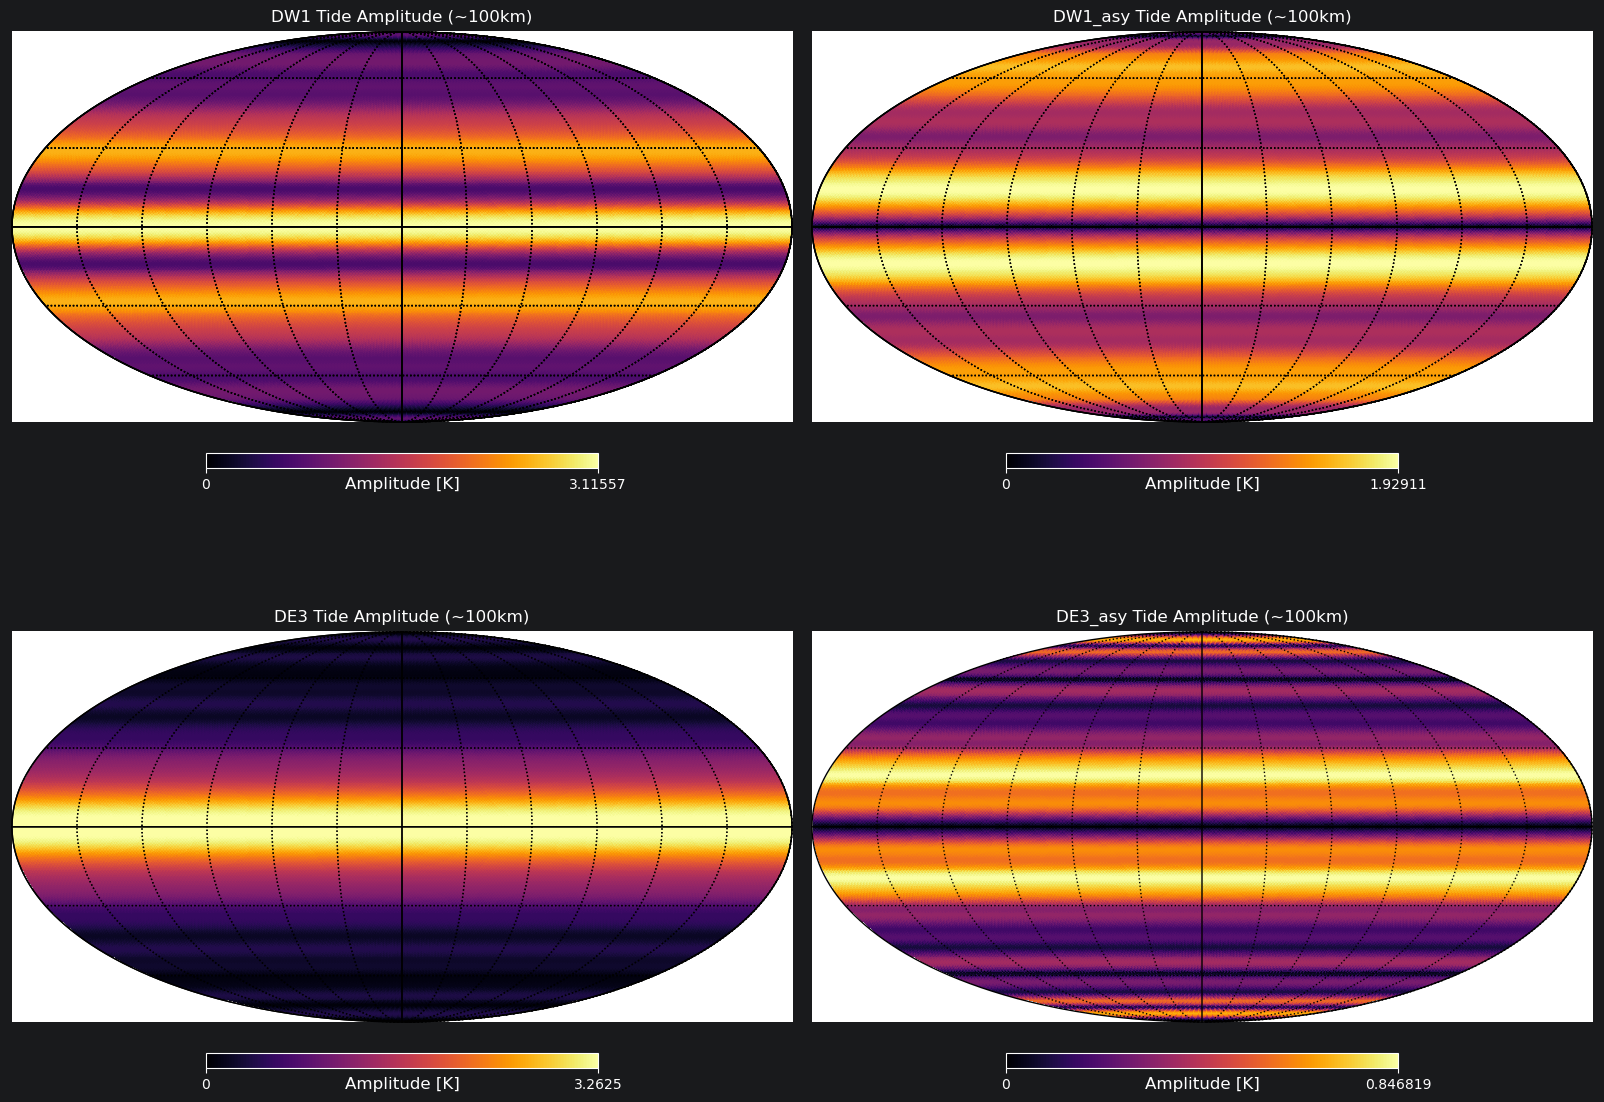

In [6]:
# Load the raw 3D dataset (not zonal mean)
ds_raw = xr.open_dataset('output_tides.nc')
target_height = 100000 # 100 km

fig = plt.figure(figsize=(16, 12))

for i, (name, meta) in enumerate(list(modes.items())[:4]):
    var_name = 'temp_amp_sym' if meta['type'] == 'Symmetric' else 'temp_amp_asy'
    data = ds_raw[var_name].sel(period=meta['period'], m=meta['m'], height=target_height, method='nearest')
    
    map_data = data.values
    map_ring = hp.reorder(map_data, n2r=True) # Reorder to RING for healpy plotting
    
    hp.mollview(map_ring, title=f"{name} Tide Amplitude (~100km)", 
                cmap='inferno', sub=(2, 2, i+1), max=float(map_data.max()), min=0, 
                unit='Amplitude [K]')
    hp.graticule()

plt.show()


## 5. Advanced Spectral Analysis: Kinetic Energy and Cross-Spectra
HealICON allows you to compute **Cross-Spectra** between any two variables, as well as the **Kinetic Energy Spectrum** derived properly from wind components or divergence/vorticity.

### Kinetic Energy Spectrum
By passing  to , HealICON automatically detects whether you provided wind components ( and ) or scalar fields ( and ).
- For wind components (), it performs a rigorous **spin-1 vector spherical harmonic transform**.
- For divergence and vorticity, it combines their scalar power spectra and properly normalizes them by ^2 / (2l(l+1))$.

Let's compute the Kinetic Energy spectrum at the surface level using both methods to see that they yield identical physical spectra:

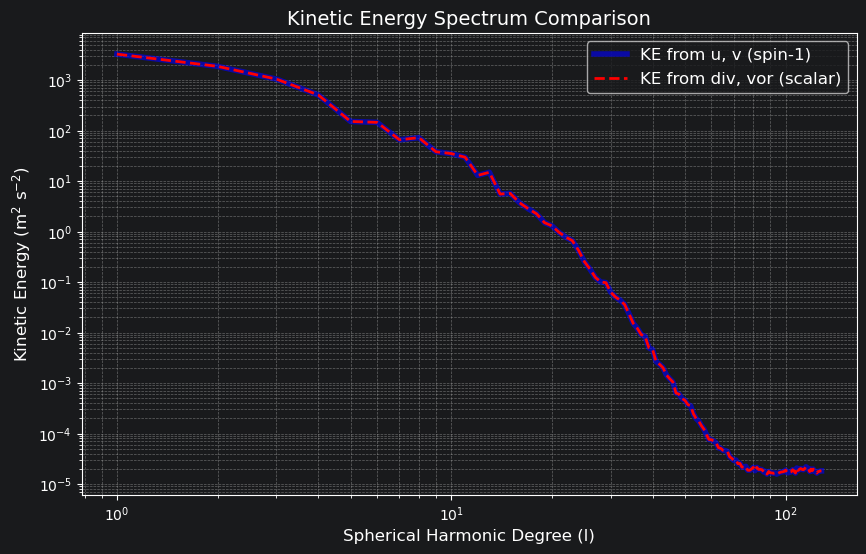

In [7]:
from healicon.analysis import compute_vorticity_divergence

# 1. Direct KE from u and v (spin-1 transform)
ke_uv = compute_spectrum(ds_hp, var_name=['u', 'v'], lmax=128, spectrum_type='kinetic').compute()

# 2. KE from Divergence and Vorticity (scalar transforms)
# First, compute divergence and vorticity from u and v
ds_dv = compute_vorticity_divergence(ds_hp, u_var='u', v_var='v', lmax=128).compute()
# Then compute their KE spectrum
ke_dv = compute_spectrum(ds_dv, var_name=['divergence', 'vorticity'], lmax=128, spectrum_type='kinetic').compute()

# Plot comparison
l = ke_uv['l'].values
cl_uv = ke_uv['kinetic_energy_cl'].values
cl_dv = ke_dv['kinetic_energy_cl'].values

plt.figure(figsize=(10, 6))
# Start from l=1 to drop the zero-mean component
plt.loglog(l[1:], cl_uv[1:], 'b-', linewidth=4, alpha=0.6, label='KE from u, v (spin-1)')
plt.loglog(l[1:], cl_dv[1:], 'r--', linewidth=2, label='KE from div, vor (scalar)')

plt.title('Kinetic Energy Spectrum Comparison', fontsize=14)
plt.xlabel('Spherical Harmonic Degree (l)', fontsize=12)
plt.ylabel('Kinetic Energy (m$^2$ s$^{-2}$)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend(fontsize=12)
plt.show()
